# EE 413 Project - Member 3: STFT-Based Analysis

This notebook completes the STFT part of the audio digit classification project.

Main tasks:
1. Implement STFT-based analysis.
2. Extract short-time spectral features.
3. Study the effects of window type, window length, and overlap.
4. Train and evaluate a classifier using STFT features.


## Stage 1: Imports and Settings


In [1]:
import os
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Main settings
RANDOM_STATE = 42
SPLIT_METHOD = "official"
TEST_SIZE = 0.20
MAX_FILES_PER_DIGIT = None

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


## Stage 2: Dataset Preparation

The notebook searches for FSDD recordings locally first. If the recordings are not found, it downloads the public FSDD repository.


In [2]:
FSDD_ZIP_URL = "https://github.com/Jakobovski/free-spoken-digit-dataset/archive/refs/heads/master.zip"

def find_recordings_folder():
    candidate_folders = [
        Path("data/recordings"),
        Path("data/recording"),
        Path("data/recording/recordings"),
        Path("recordings"),
        Path("free-spoken-digit-dataset/recordings"),
        Path("free-spoken-digit-dataset-master/recordings"),
        Path("../data/recordings"),
        Path("../recordings"),
    ]

    # Search for local recordings
    for folder in candidate_folders:
        if folder.exists():
            wav_files = sorted(folder.rglob("*.wav"))
            if len(wav_files) > 0:
                return folder, wav_files

    return None, []

def download_fsdd_if_needed():
    folder, wav_files = find_recordings_folder()

    if len(wav_files) > 0:
        print("Recordings folder:", folder)
        print("Number of WAV files:", len(wav_files))
        return folder, wav_files

    # Download FSDD if it is not available locally
    zip_path = Path("fsdd_dataset.zip")
    extract_dir = Path(".")

    urllib.request.urlretrieve(FSDD_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    folder, wav_files = find_recordings_folder()

    print("Recordings folder:", folder)
    print("Number of WAV files:", len(wav_files))

    return folder, wav_files

recordings_folder, wav_files = download_fsdd_if_needed()


Recordings folder: free-spoken-digit-dataset-master/recordings
Number of WAV files: 3000


## Stage 3: Metadata Table

The file name format is:

```text
digit_speaker_index.wav
```

The recording index is also used to create the official FSDD split.


In [3]:
def parse_fsdd_filename(file_path):
    file_path = Path(file_path)
    parts = file_path.stem.split("_")

    digit = int(parts[0]) if len(parts) >= 1 and parts[0].isdigit() else -1
    speaker = parts[1] if len(parts) >= 2 else "unknown"

    try:
        recording_index = int(parts[2]) if len(parts) >= 3 else -1
    except ValueError:
        recording_index = -1

    if recording_index >= 0:
        split = "test" if recording_index <= 4 else "train"
    else:
        split = "unknown"

    return {
        "file_name": file_path.name,
        "path": str(file_path),
        "digit": digit,
        "speaker": speaker,
        "recording_index": recording_index,
        "split": split,
    }

# Create metadata table
file_table = pd.DataFrame([parse_fsdd_filename(path) for path in wav_files])
file_table = file_table[file_table["digit"].between(0, 9)].reset_index(drop=True)

if MAX_FILES_PER_DIGIT is not None:
    file_table = (
        file_table
        .groupby("digit", group_keys=False)
        .head(MAX_FILES_PER_DIGIT)
        .reset_index(drop=True)
    )

print("Total files:", len(file_table))
display(file_table.head())
display(file_table["digit"].value_counts().sort_index())


Total files: 3000


,file_name,path,digit,speaker,recording_index,split
0,0_george_0.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,0,test
1,0_george_1.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,1,test
2,0_george_10.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,10,train
3,0_george_11.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,11,train
4,0_george_12.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,12,train


,count
digit,
0,300
1,300
2,300
3,300
4,300
5,300
6,300
7,300
8,300


## Stage 4: Audio Loading and Example Waveform


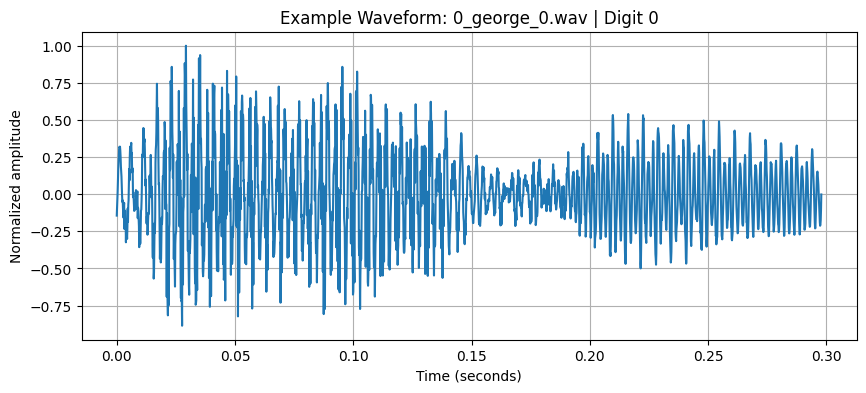

Sample rate: 8000
Signal length: 2384
Duration: 0.298 seconds


In [4]:
def load_audio(file_path):
    sample_rate, signal = wavfile.read(file_path)
    original_dtype = signal.dtype

    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    # Normalize audio
    signal = signal.astype(np.float32)

    if np.issubdtype(original_dtype, np.integer):
        max_value = max(abs(np.iinfo(original_dtype).min), np.iinfo(original_dtype).max)
        signal = signal / max_value

    signal = signal - np.mean(signal)

    max_abs = np.max(np.abs(signal))
    if max_abs > 0:
        signal = signal / max_abs

    return signal, sample_rate

example_row = file_table.iloc[0]
example_signal, example_sr = load_audio(example_row["path"])

# Plot example waveform
time_axis = np.arange(len(example_signal)) / example_sr

plt.figure(figsize=(10, 4))
plt.plot(time_axis, example_signal)
plt.title(f"Example Waveform: {example_row['file_name']} | Digit {example_row['digit']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.grid()
plt.show()

print("Sample rate:", example_sr)
print("Signal length:", len(example_signal))
print("Duration:", len(example_signal) / example_sr, "seconds")


## Stage 5: Manual STFT Implementation

The signal is divided into short frames. Each frame is multiplied by a window, then the FFT is applied.


In [5]:
def get_window(window_type, frame_length):
    window_type = window_type.lower()

    if window_type in ["rectangular", "boxcar", "rect"]:
        return np.ones(frame_length)
    elif window_type in ["hann", "hanning"]:
        return np.hanning(frame_length)
    elif window_type == "hamming":
        return np.hamming(frame_length)
    elif window_type == "blackman":
        return np.blackman(frame_length)
    else:
        raise ValueError("Use rectangular, hann, hamming, or blackman.")

def frame_signal(signal, frame_length, hop_length):
    if len(signal) < frame_length:
        pad_amount = frame_length - len(signal)
        signal = np.pad(signal, (0, pad_amount))

    number_of_frames = 1 + int(np.ceil((len(signal) - frame_length) / hop_length))
    target_length = frame_length + (number_of_frames - 1) * hop_length

    if len(signal) < target_length:
        signal = np.pad(signal, (0, target_length - len(signal)))

    # Split signal into frames
    frames = []

    for frame_index in range(number_of_frames):
        start = frame_index * hop_length
        end = start + frame_length
        frames.append(signal[start:end])

    return np.array(frames)

def compute_stft(signal, sample_rate, window_type="hann", frame_length=256, overlap=0.50, n_fft=None):
    if n_fft is None:
        n_fft = frame_length

    hop_length = int(frame_length * (1 - overlap))
    hop_length = max(1, hop_length)

    frames = frame_signal(signal, frame_length, hop_length)
    window = get_window(window_type, frame_length)

    # FFT for each windowed frame
    stft_values = []

    for frame in frames:
        windowed_frame = frame * window
        spectrum = np.fft.rfft(windowed_frame, n=n_fft)
        stft_values.append(spectrum)

    stft_values = np.array(stft_values)
    magnitude = np.abs(stft_values)
    power = magnitude ** 2
    frequencies = np.fft.rfftfreq(n_fft, d=1 / sample_rate)
    times = np.arange(len(frames)) * hop_length / sample_rate

    return {
        "stft": stft_values,
        "magnitude": magnitude,
        "power": power,
        "frequencies": frequencies,
        "times": times,
        "frame_length": frame_length,
        "hop_length": hop_length,
        "overlap": overlap,
        "window_type": window_type,
        "sample_rate": sample_rate,
    }

example_stft = compute_stft(
    example_signal,
    example_sr,
    window_type="hann",
    frame_length=256,
    overlap=0.50,
)

print("STFT shape:", example_stft["stft"].shape)
print("Frame length:", example_stft["frame_length"])
print("Hop length:", example_stft["hop_length"])
print("Frequency bins:", len(example_stft["frequencies"]))


STFT shape: (18, 129)
Frame length: 256
Hop length: 128
Frequency bins: 129


## Stage 6: STFT Spectrogram


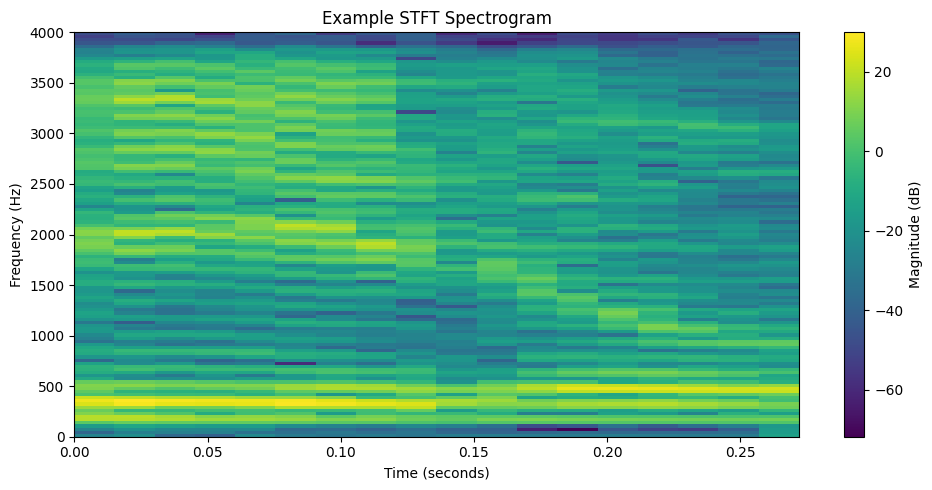

In [6]:
def plot_stft_spectrogram(stft_result, title, save_path=None):
    magnitude = stft_result["magnitude"]
    frequencies = stft_result["frequencies"]
    times = stft_result["times"]

    # Convert magnitude to dB
    magnitude_db = 20 * np.log10(magnitude.T + 1e-8)

    plt.figure(figsize=(10, 5))

    if len(times) > 1:
        extent = [times[0], times[-1], frequencies[0], frequencies[-1]]
    else:
        extent = [0, len(example_signal) / example_sr, frequencies[0], frequencies[-1]]

    plt.imshow(magnitude_db, origin="lower", aspect="auto", extent=extent)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude (dB)")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

plot_stft_spectrogram(
    example_stft,
    "Example STFT Spectrogram",
    RESULTS_DIR / "stft_example_spectrogram.png",
)


## Stage 7: Compare STFT Window Types on One Signal


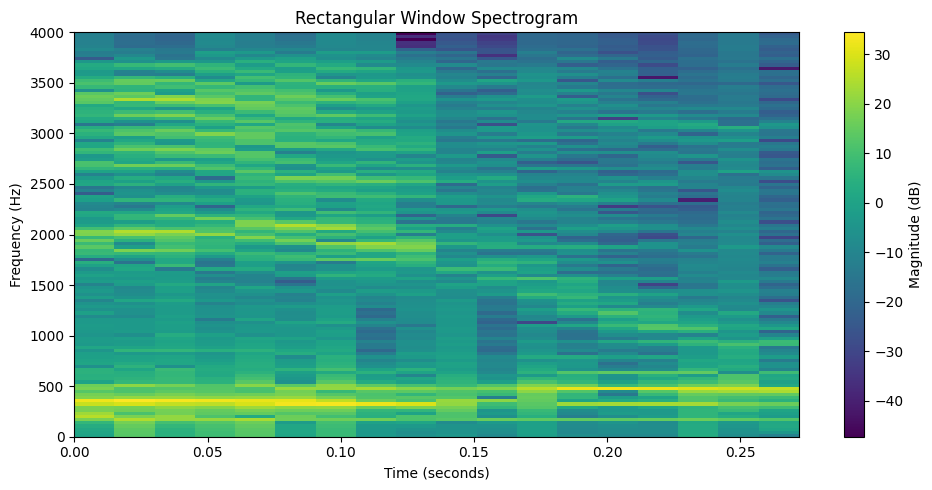

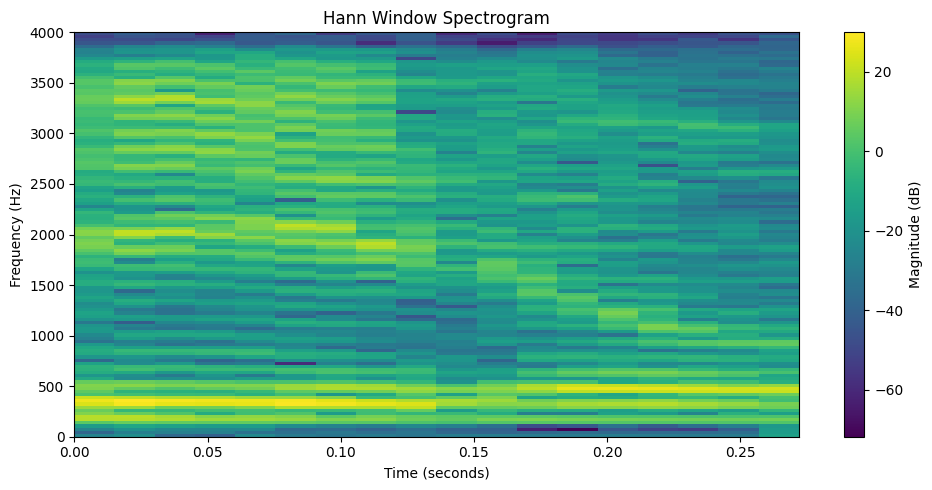

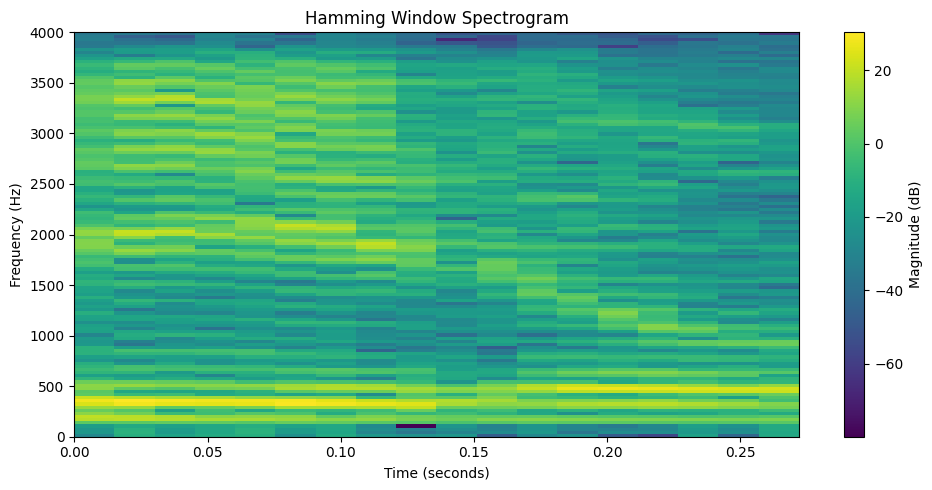

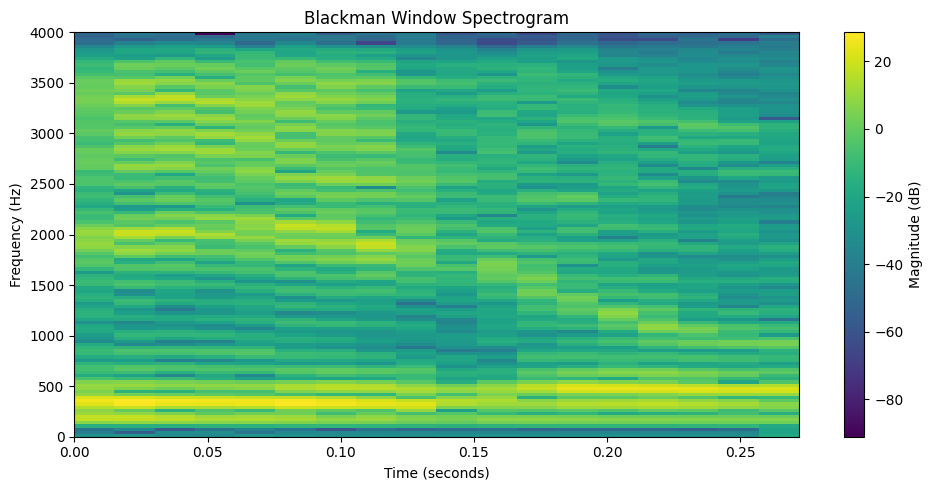

In [7]:
def compare_window_types_separate(signal, sample_rate, frame_length=256, overlap=0.50):
    window_types = ["rectangular", "hann", "hamming", "blackman"]

    # Plot each window type separately
    for window_type in window_types:
        result = compute_stft(
            signal,
            sample_rate,
            window_type=window_type,
            frame_length=frame_length,
            overlap=overlap,
        )

        plot_stft_spectrogram(
            result,
            f"{window_type.capitalize()} Window Spectrogram",
            RESULTS_DIR / f"stft_spectrogram_{window_type}.png",
        )

compare_window_types_separate(example_signal, example_sr)


## Stage 8: Compare STFT Window Lengths on One Signal


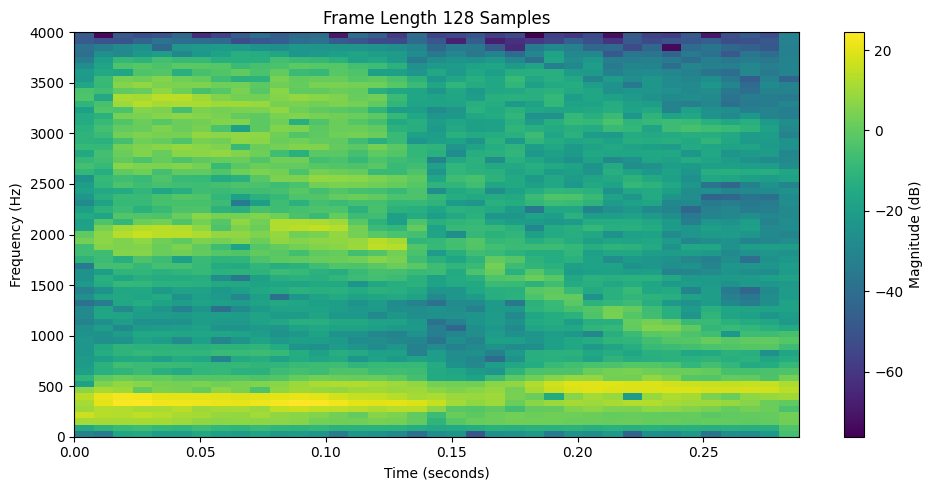

Frame length: 128
Time length: 0.016 seconds
Frequency resolution: 62.5 Hz



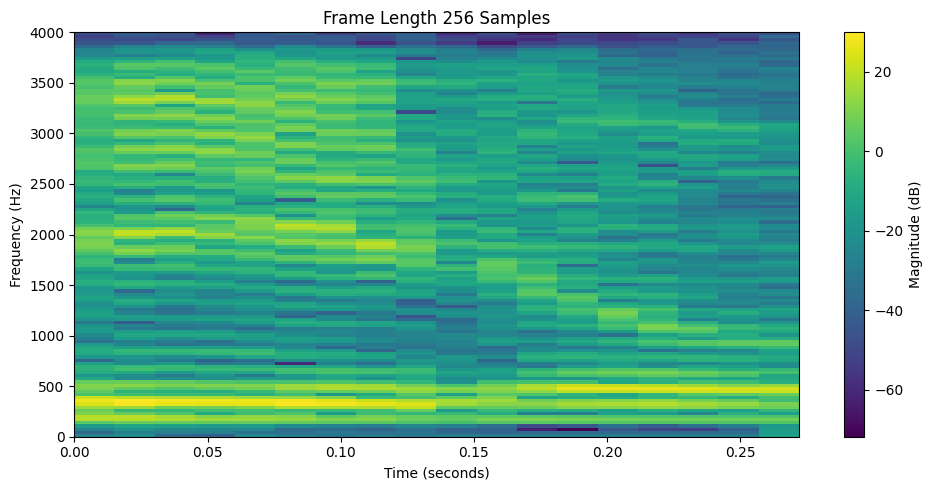

Frame length: 256
Time length: 0.032 seconds
Frequency resolution: 31.25 Hz



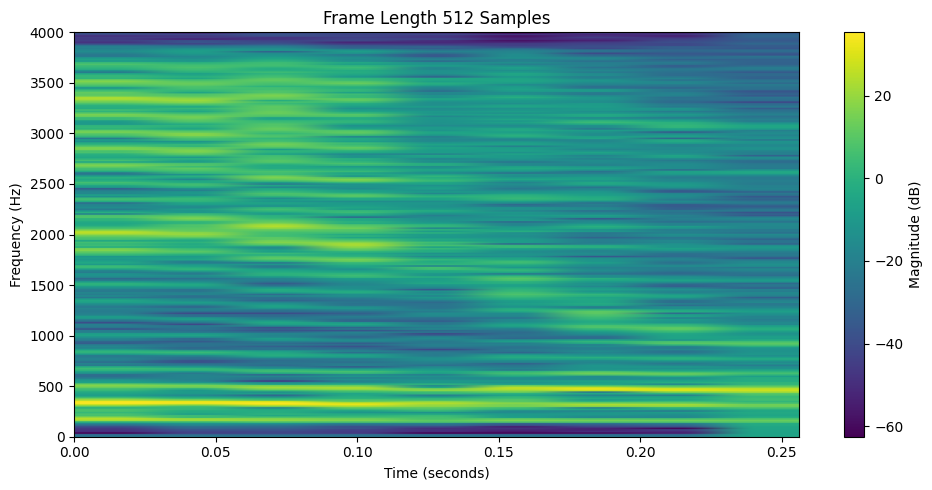

Frame length: 512
Time length: 0.064 seconds
Frequency resolution: 15.625 Hz



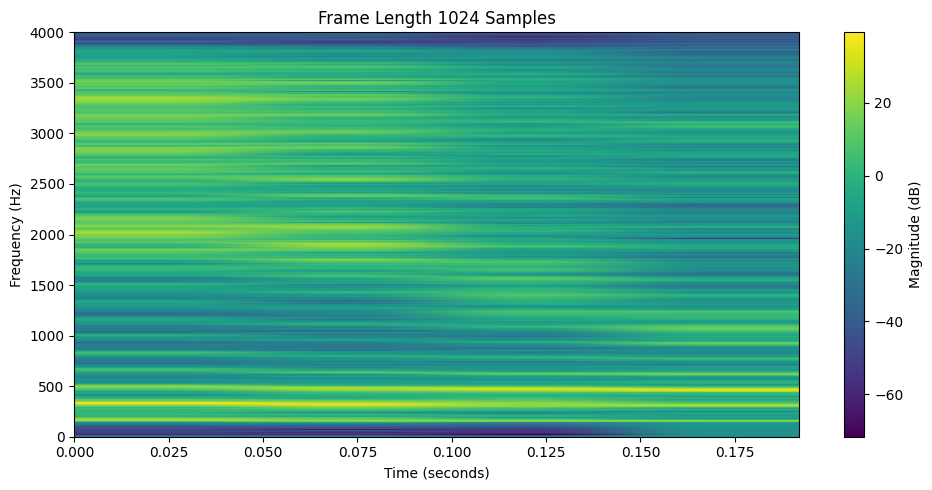

Frame length: 1024
Time length: 0.128 seconds
Frequency resolution: 7.8125 Hz



In [8]:
def compare_window_lengths_separate(signal, sample_rate, window_type="hann", overlap=0.50):
    frame_lengths = [128, 256, 512, 1024]

    # Plot each frame length separately
    for frame_length in frame_lengths:
        result = compute_stft(
            signal,
            sample_rate,
            window_type=window_type,
            frame_length=frame_length,
            overlap=overlap,
        )

        delta_f = sample_rate / frame_length
        time_length = frame_length / sample_rate

        plot_stft_spectrogram(
            result,
            f"Frame Length {frame_length} Samples",
            RESULTS_DIR / f"stft_spectrogram_frame_{frame_length}.png",
        )

        print("Frame length:", frame_length)
        print("Time length:", time_length, "seconds")
        print("Frequency resolution:", delta_f, "Hz")
        print()

compare_window_lengths_separate(example_signal, example_sr)


## Stage 9: Compare STFT Overlap on One Signal


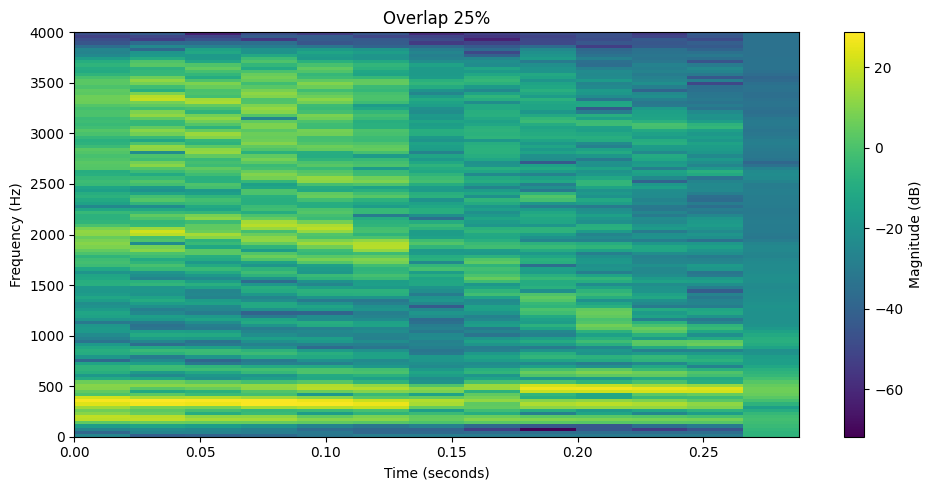

Overlap: 0.25
Hop length: 192
Number of frames: 13



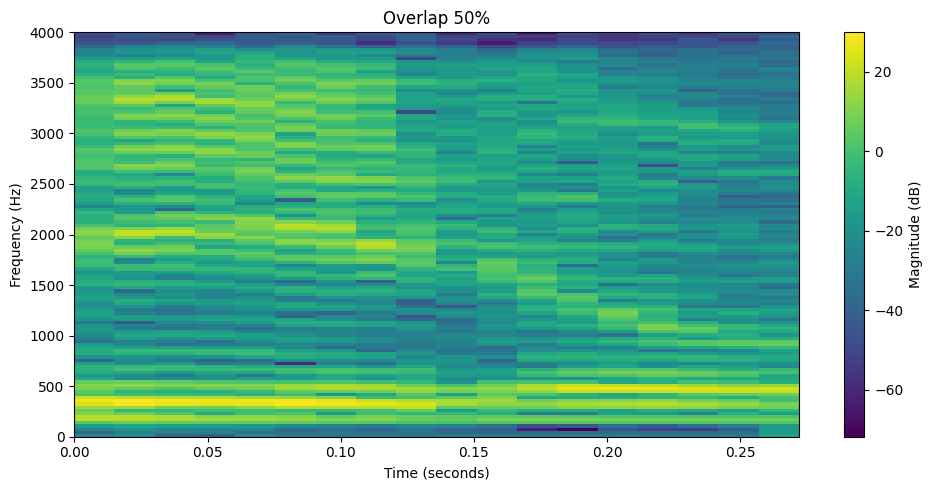

Overlap: 0.5
Hop length: 128
Number of frames: 18



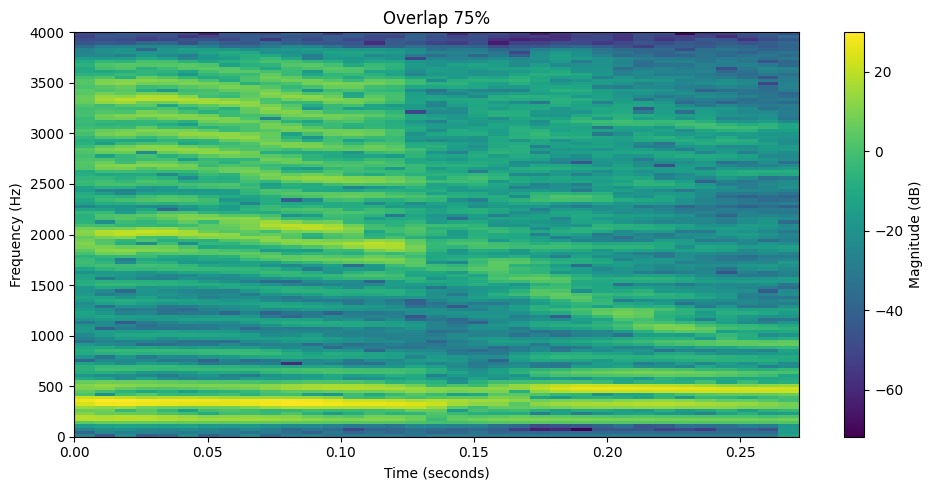

Overlap: 0.75
Hop length: 64
Number of frames: 35



In [9]:
def compare_overlap_separate(signal, sample_rate, window_type="hann", frame_length=256):
    overlaps = [0.25, 0.50, 0.75]

    # Plot each overlap separately
    for overlap in overlaps:
        result = compute_stft(
            signal,
            sample_rate,
            window_type=window_type,
            frame_length=frame_length,
            overlap=overlap,
        )

        plot_stft_spectrogram(
            result,
            f"Overlap {int(overlap * 100)}%",
            RESULTS_DIR / f"stft_spectrogram_overlap_{int(overlap * 100)}.png",
        )

        print("Overlap:", overlap)
        print("Hop length:", result["hop_length"])
        print("Number of frames:", result["magnitude"].shape[0])
        print()

compare_overlap_separate(example_signal, example_sr)


## Stage 10: Short-Time Spectral Feature Extraction

Each recording is converted into one feature vector by summarizing spectral measurements across all STFT frames.


In [10]:
def summarize_vector(values, prefix):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {
            f"{prefix}_mean": 0.0,
            f"{prefix}_std": 0.0,
            f"{prefix}_min": 0.0,
            f"{prefix}_max": 0.0,
        }

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
    }

def band_energy_ratio(power, frequencies, low_freq, high_freq):
    total_power = np.sum(power, axis=1) + 1e-12
    band_mask = (frequencies >= low_freq) & (frequencies < high_freq)
    band_power = np.sum(power[:, band_mask], axis=1)
    return band_power / total_power

def extract_stft_features(signal, sample_rate, window_type="hann", frame_length=256, overlap=0.50, n_fft=None):
    result = compute_stft(
        signal,
        sample_rate,
        window_type=window_type,
        frame_length=frame_length,
        overlap=overlap,
        n_fft=n_fft,
    )

    magnitude = result["magnitude"]
    power = result["power"]
    frequencies = result["frequencies"]

    total_power = np.sum(power, axis=1) + 1e-12

    # Short-time spectral features
    centroid = np.sum(power * frequencies, axis=1) / total_power
    bandwidth = np.sqrt(np.sum(power * (frequencies - centroid[:, None]) ** 2, axis=1) / total_power)

    cumulative_power = np.cumsum(power, axis=1)
    rolloff_threshold = 0.85 * total_power
    rolloff_indices = np.argmax(cumulative_power >= rolloff_threshold[:, None], axis=1)
    rolloff = frequencies[rolloff_indices]

    dominant_indices = np.argmax(magnitude, axis=1)
    dominant_frequency = frequencies[dominant_indices]

    normalized_magnitude = magnitude / (np.sum(magnitude, axis=1, keepdims=True) + 1e-12)

    if normalized_magnitude.shape[0] > 1:
        spectral_flux = np.sqrt(np.sum(np.diff(normalized_magnitude, axis=0) ** 2, axis=1))
    else:
        spectral_flux = np.array([0.0])

    spectral_entropy = -np.sum(
        normalized_magnitude * np.log2(normalized_magnitude + 1e-12),
        axis=1,
    ) / np.log2(normalized_magnitude.shape[1])

    # Band energy ratios
    low_band = band_energy_ratio(power, frequencies, 0, 1000)
    mid_band = band_energy_ratio(power, frequencies, 1000, 2500)
    high_band = band_energy_ratio(power, frequencies, 2500, sample_rate / 2)

    frame_energy = np.mean(power, axis=1)

    # Summarize frames into one feature vector
    features = {}
    features.update(summarize_vector(centroid, "centroid"))
    features.update(summarize_vector(bandwidth, "bandwidth"))
    features.update(summarize_vector(rolloff, "rolloff"))
    features.update(summarize_vector(dominant_frequency, "dominant_freq"))
    features.update(summarize_vector(spectral_flux, "flux"))
    features.update(summarize_vector(spectral_entropy, "entropy"))
    features.update(summarize_vector(low_band, "low_band_ratio"))
    features.update(summarize_vector(mid_band, "mid_band_ratio"))
    features.update(summarize_vector(high_band, "high_band_ratio"))
    features.update(summarize_vector(frame_energy, "frame_energy"))

    features["number_of_frames"] = magnitude.shape[0]
    features["duration"] = len(signal) / sample_rate
    features["window_type"] = window_type
    features["frame_length"] = frame_length
    features["overlap"] = overlap

    return features

example_features = extract_stft_features(example_signal, example_sr)
display(pd.DataFrame([example_features]).T.head(20))


,0
centroid_mean,623.568094
centroid_std,172.935474
centroid_min,458.456183
centroid_max,1004.089448
bandwidth_mean,590.466132
bandwidth_std,333.599474
bandwidth_min,133.326869
bandwidth_max,1128.106682
rolloff_mean,1196.180556
rolloff_std,841.741795


## Stage 11: Build the STFT Feature Table


In [11]:
def extract_stft_feature_table(file_table, window_type="hann", frame_length=256, overlap=0.50, n_fft=None):
    rows = []

    # Extract features for all files
    for row_index, row in file_table.iterrows():
        signal, sample_rate = load_audio(row["path"])

        features = extract_stft_features(
            signal,
            sample_rate,
            window_type=window_type,
            frame_length=frame_length,
            overlap=overlap,
            n_fft=n_fft,
        )

        features["file_name"] = row["file_name"]
        features["path"] = row["path"]
        features["digit"] = int(row["digit"])
        features["speaker"] = row["speaker"]
        features["recording_index"] = int(row["recording_index"])
        features["split"] = row["split"]
        features["sample_rate"] = sample_rate

        rows.append(features)

    return pd.DataFrame(rows)

def get_or_create_stft_features(file_table, window_type="hann", frame_length=256, overlap=0.50, use_cache=True):
    overlap_name = int(overlap * 100)
    cache_path = RESULTS_DIR / f"stft_features_{window_type}_{frame_length}_{overlap_name}.csv"

    # Use saved features if available
    if use_cache and cache_path.exists():
        return pd.read_csv(cache_path)

    features_df = extract_stft_feature_table(
        file_table,
        window_type=window_type,
        frame_length=frame_length,
        overlap=overlap,
    )

    features_df.to_csv(cache_path, index=False)

    return features_df

baseline_features = get_or_create_stft_features(
    file_table,
    window_type="hann",
    frame_length=256,
    overlap=0.50,
)

print("Feature table shape:", baseline_features.shape)
display(baseline_features.head())


Feature table shape: (3000, 52)


,centroid_mean,centroid_std,centroid_min,centroid_max,bandwidth_mean,bandwidth_std,bandwidth_min,bandwidth_max,rolloff_mean,rolloff_std,...,window_type,frame_length,overlap,file_name,path,digit,speaker,recording_index,split,sample_rate
0,623.568094,172.935474,458.456183,1004.089448,590.466132,333.599474,133.326869,1128.106682,1196.180556,841.741795,...,hann,256,0.5,0_george_0.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,0,test,8000
1,475.555750,157.290254,224.287426,892.198693,397.455149,197.907527,107.420129,859.244992,643.229167,419.804267,...,hann,256,0.5,0_george_1.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,1,test,8000
2,758.746799,515.744414,233.026008,2199.922640,556.446566,329.486930,114.039932,1107.386510,1205.163043,1000.926290,...,hann,256,0.5,0_george_10.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,10,train,8000
3,603.532310,290.554761,252.159497,1253.476062,509.475574,288.716148,192.074689,994.603838,852.678571,650.638055,...,hann,256,0.5,0_george_11.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,11,train,8000
4,576.644640,317.427864,210.062962,1321.908579,487.964500,295.748399,128.744780,950.512793,862.903226,662.992315,...,hann,256,0.5,0_george_12.wav,free-spoken-digit-dataset-master/recordings/0_...,0,george,12,train,8000


## Stage 12: STFT Classification


Baseline configuration: Hann window, frame length = 256, overlap = 50%
Split used: official
Number of STFT feature columns: 44
Baseline accuracy: 0.9

              precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.79      0.87      0.83        30
           2       0.94      0.97      0.95        30
           3       0.85      0.77      0.81        30
           4       1.00      0.97      0.98        30
           5       0.94      0.97      0.95        30
           6       0.97      0.97      0.97        30
           7       0.90      0.93      0.92        30
           8       0.87      0.87      0.87        30
           9       0.90      0.93      0.92        30

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



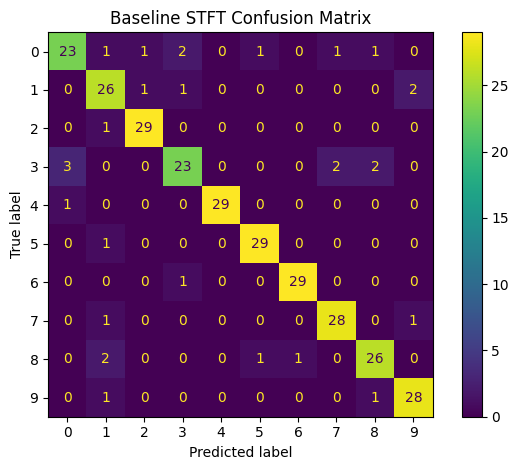

In [12]:
NON_FEATURE_COLUMNS = {
    "file_name",
    "path",
    "digit",
    "speaker",
    "recording_index",
    "split",
    "sample_rate",
    "window_type",
}

def get_feature_columns(features_df):
    feature_columns = []

    # Keep numeric feature columns only
    for column in features_df.columns:
        if column in NON_FEATURE_COLUMNS:
            continue

        if pd.api.types.is_numeric_dtype(features_df[column]):
            feature_columns.append(column)

    return feature_columns

def split_feature_table(features_df, feature_columns, split_method="official"):
    # Official FSDD split
    if split_method == "official" and set(features_df["split"].unique()) >= {"train", "test"}:
        train_df = features_df[features_df["split"] == "train"]
        test_df = features_df[features_df["split"] == "test"]

        X_train = train_df[feature_columns].values
        y_train = train_df["digit"].values
        X_test = test_df[feature_columns].values
        y_test = test_df["digit"].values

        return X_train, X_test, y_train, y_test, "official"

    X = features_df[feature_columns].values
    y = features_df["digit"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    return X_train, X_test, y_train, y_test, "random stratified"

def evaluate_stft_classifier(features_df, split_method="official"):
    feature_columns = get_feature_columns(features_df)
    X_train, X_test, y_train, y_test, split_used = split_feature_table(
        features_df,
        feature_columns,
        split_method=split_method,
    )

    # Train SVM classifier
    classifier = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE)),
    ])

    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return {
        "classifier": classifier,
        "feature_columns": feature_columns,
        "split_used": split_used,
        "accuracy": accuracy,
        "y_test": y_test,
        "y_pred": y_pred,
    }

baseline_eval = evaluate_stft_classifier(baseline_features, split_method=SPLIT_METHOD)

print("Baseline configuration: Hann window, frame length = 256, overlap = 50%")
print("Split used:", baseline_eval["split_used"])
print("Number of STFT feature columns:", len(baseline_eval["feature_columns"]))
print("Baseline accuracy:", round(baseline_eval["accuracy"], 4))
print()
print(classification_report(baseline_eval["y_test"], baseline_eval["y_pred"]))

baseline_cm = confusion_matrix(baseline_eval["y_test"], baseline_eval["y_pred"], labels=list(range(10)))

disp = ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=list(range(10)))
disp.plot(values_format="d")
plt.title("Baseline STFT Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stft_baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Stage 13: Study the Effect of Window Type


Window type: rectangular
Accuracy: 0.8633

Window type: hann
Accuracy: 0.9

Window type: hamming
Accuracy: 0.9033

Window type: blackman
Accuracy: 0.91



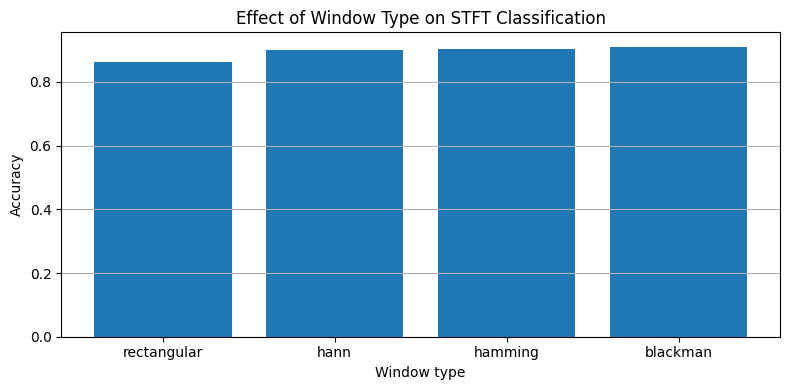

,window_type,frame_length,overlap,accuracy,split_used,number_of_features
0,rectangular,256,0.5,0.863333,official,44
1,hann,256,0.5,0.900000,official,44
2,hamming,256,0.5,0.903333,official,44
3,blackman,256,0.5,0.910000,official,44


In [13]:
def run_single_stft_experiment(window_type, frame_length, overlap):
    features_df = get_or_create_stft_features(
        file_table,
        window_type=window_type,
        frame_length=frame_length,
        overlap=overlap,
        use_cache=True,
    )

    evaluation = evaluate_stft_classifier(features_df, split_method=SPLIT_METHOD)

    return {
        "window_type": window_type,
        "frame_length": frame_length,
        "overlap": overlap,
        "accuracy": evaluation["accuracy"],
        "split_used": evaluation["split_used"],
        "number_of_features": len(evaluation["feature_columns"]),
    }

def compare_window_type_accuracy():
    rows = []
    window_types = ["rectangular", "hann", "hamming", "blackman"]

    # Test different window functions
    for window_type in window_types:
        result = run_single_stft_experiment(
            window_type=window_type,
            frame_length=256,
            overlap=0.50,
        )

        rows.append(result)

        print("Window type:", window_type)
        print("Accuracy:", round(result["accuracy"], 4))
        print()

    results_df = pd.DataFrame(rows)

    plt.figure(figsize=(8, 4))
    plt.bar(results_df["window_type"], results_df["accuracy"])
    plt.title("Effect of Window Type on STFT Classification")
    plt.xlabel("Window type")
    plt.ylabel("Accuracy")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "stft_accuracy_by_window_type.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results_df

window_type_results = compare_window_type_accuracy()
display(window_type_results)


## Stage 14: Study the Effect of Window Length


Frame length: 128
Time length: 0.016 seconds
Frequency resolution: 62.5 Hz
Accuracy: 0.91

Frame length: 256
Time length: 0.032 seconds
Frequency resolution: 31.25 Hz
Accuracy: 0.9

Frame length: 512
Time length: 0.064 seconds
Frequency resolution: 15.625 Hz
Accuracy: 0.88

Frame length: 1024
Time length: 0.128 seconds
Frequency resolution: 7.8125 Hz
Accuracy: 0.85



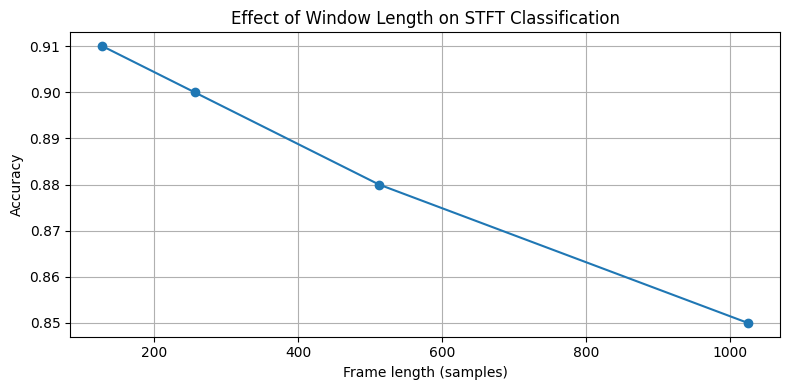

,window_type,frame_length,overlap,accuracy,split_used,number_of_features
0,hann,128,0.5,0.91,official,44
1,hann,256,0.5,0.90,official,44
2,hann,512,0.5,0.88,official,44
3,hann,1024,0.5,0.85,official,44


In [14]:
def compare_window_length_accuracy():
    rows = []
    frame_lengths = [128, 256, 512, 1024]

    # Test different frame lengths
    for frame_length in frame_lengths:
        result = run_single_stft_experiment(
            window_type="hann",
            frame_length=frame_length,
            overlap=0.50,
        )

        rows.append(result)

        delta_f = example_sr / frame_length
        time_length = frame_length / example_sr

        print("Frame length:", frame_length)
        print("Time length:", time_length, "seconds")
        print("Frequency resolution:", delta_f, "Hz")
        print("Accuracy:", round(result["accuracy"], 4))
        print()

    results_df = pd.DataFrame(rows)

    plt.figure(figsize=(8, 4))
    plt.plot(results_df["frame_length"], results_df["accuracy"], marker="o")
    plt.title("Effect of Window Length on STFT Classification")
    plt.xlabel("Frame length (samples)")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "stft_accuracy_by_window_length.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results_df

window_length_results = compare_window_length_accuracy()
display(window_length_results)


## Stage 15: Study the Effect of Overlap


Overlap: 0.25
Hop length: 192
Accuracy: 0.8933

Overlap: 0.5
Hop length: 128
Accuracy: 0.9

Overlap: 0.75
Hop length: 64
Accuracy: 0.9



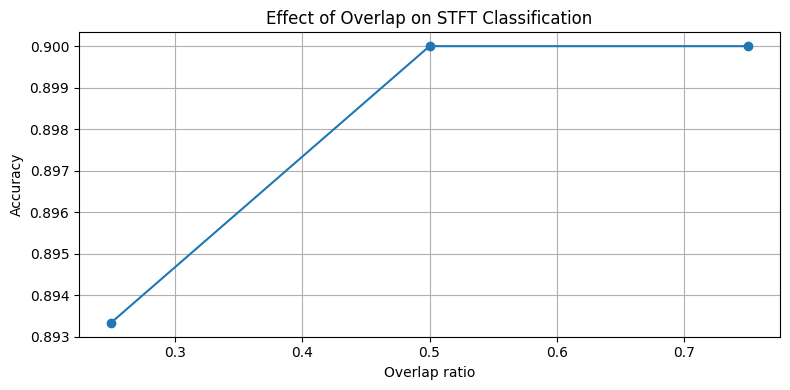

,window_type,frame_length,overlap,accuracy,split_used,number_of_features
0,hann,256,0.25,0.893333,official,44
1,hann,256,0.50,0.900000,official,44
2,hann,256,0.75,0.900000,official,44


In [15]:
def compare_overlap_accuracy():
    rows = []
    overlaps = [0.25, 0.50, 0.75]

    # Test different overlap ratios
    for overlap in overlaps:
        result = run_single_stft_experiment(
            window_type="hann",
            frame_length=256,
            overlap=overlap,
        )

        rows.append(result)

        hop_length = int(256 * (1 - overlap))

        print("Overlap:", overlap)
        print("Hop length:", hop_length)
        print("Accuracy:", round(result["accuracy"], 4))
        print()

    results_df = pd.DataFrame(rows)

    plt.figure(figsize=(8, 4))
    plt.plot(results_df["overlap"], results_df["accuracy"], marker="o")
    plt.title("Effect of Overlap on STFT Classification")
    plt.xlabel("Overlap ratio")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "stft_accuracy_by_overlap.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results_df

overlap_results = compare_overlap_accuracy()
display(overlap_results)


## Stage 16: Combine Results and Select the Best STFT Configuration


Best STFT configuration:


,value
window_type,hann
frame_length,128
overlap,0.5
accuracy,0.91
split_used,official
number_of_features,44


Best configuration accuracy: 0.91

              precision    recall  f1-score   support

           0       0.93      0.87      0.90        30
           1       0.76      0.87      0.81        30
           2       1.00      0.87      0.93        30
           3       0.93      0.83      0.88        30
           4       0.94      0.97      0.95        30
           5       0.94      0.97      0.95        30
           6       1.00      1.00      1.00        30
           7       0.85      0.93      0.89        30
           8       0.85      0.93      0.89        30
           9       0.96      0.87      0.91        30

    accuracy                           0.91       300
   macro avg       0.92      0.91      0.91       300
weighted avg       0.92      0.91      0.91       300



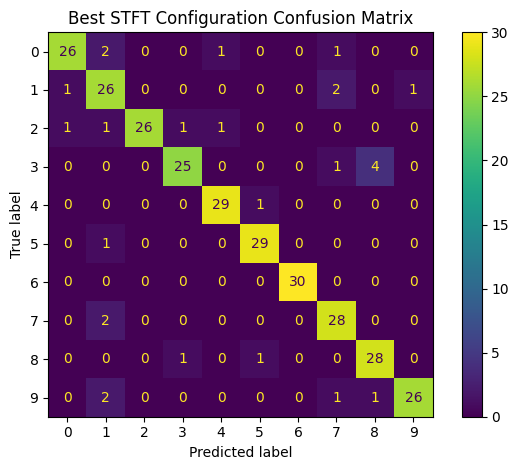

In [16]:
# Combine all experiments
experiment_results = pd.concat(
    [
        window_type_results,
        window_length_results,
        overlap_results,
    ],
    ignore_index=True,
)

experiment_results = experiment_results.drop_duplicates(
    subset=["window_type", "frame_length", "overlap"]
)

experiment_results = experiment_results.sort_values("accuracy", ascending=False).reset_index(drop=True)
experiment_results.to_csv(RESULTS_DIR / "stft_experiment_results.csv", index=False)

best_config = experiment_results.iloc[0]

print("Best STFT configuration:")
display(best_config.to_frame(name="value"))

best_features = get_or_create_stft_features(
    file_table,
    window_type=best_config["window_type"],
    frame_length=int(best_config["frame_length"]),
    overlap=float(best_config["overlap"]),
    use_cache=True,
)

best_eval = evaluate_stft_classifier(best_features, split_method=SPLIT_METHOD)

print("Best configuration accuracy:", round(best_eval["accuracy"], 4))
print()
print(classification_report(best_eval["y_test"], best_eval["y_pred"]))

best_cm = confusion_matrix(best_eval["y_test"], best_eval["y_pred"], labels=list(range(10)))

disp = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=list(range(10)))
disp.plot(values_format="d")
plt.title("Best STFT Configuration Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stft_best_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Stage 17: Hardest and Easiest Digits


Digits sorted from hardest to easiest:


,digit,correct,total,per_digit_accuracy
3,3,25,30,0.833333
0,0,26,30,0.866667
1,1,26,30,0.866667
2,2,26,30,0.866667
9,9,26,30,0.866667
7,7,28,30,0.933333
8,8,28,30,0.933333
4,4,29,30,0.966667
5,5,29,30,0.966667
6,6,30,30,1.000000


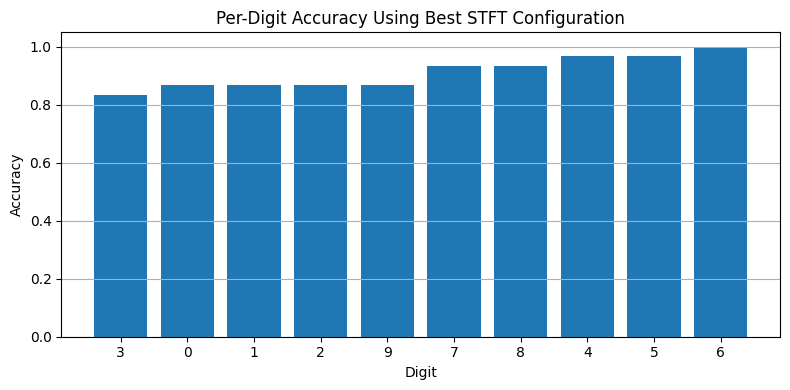

In [17]:
def per_digit_accuracy(confusion_mat):
    rows = []

    # Calculate accuracy for each digit
    for digit in range(confusion_mat.shape[0]):
        total = np.sum(confusion_mat[digit, :])
        correct = confusion_mat[digit, digit]
        accuracy = correct / total if total > 0 else 0.0

        rows.append({
            "digit": digit,
            "correct": int(correct),
            "total": int(total),
            "per_digit_accuracy": accuracy,
        })

    return pd.DataFrame(rows)

digit_accuracy = per_digit_accuracy(best_cm).sort_values("per_digit_accuracy")
digit_accuracy.to_csv(RESULTS_DIR / "stft_per_digit_accuracy.csv", index=False)

print("Digits sorted from hardest to easiest:")
display(digit_accuracy)

plt.figure(figsize=(8, 4))
plt.bar(digit_accuracy["digit"].astype(str), digit_accuracy["per_digit_accuracy"])
plt.title("Per-Digit Accuracy Using Best STFT Configuration")
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stft_per_digit_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


## Stage 18: Summary for Presentation


## Stage 18: Summary for Presentation

**objective: STFT-Based Analysis**

**Method:** Manual STFT feature extraction

**Baseline configuration:** Hann window, 256 samples, 50% overlap

**Values to report after running the notebook:**

- Baseline accuracy: from `baseline_eval["accuracy"]`
- Best window type: from `best_config["window_type"]`
- Best frame length: from `best_config["frame_length"]`
- Best overlap: from `best_config["overlap"]`
- Best accuracy: from `best_eval["accuracy"]`
- Hardest digit: first row in `digit_accuracy`
- Hardest digit accuracy: first row in `digit_accuracy`

**Feature groups used:**

- Spectral centroid
- Spectral bandwidth
- Spectral rolloff
- Dominant frequency
- Spectral flux
- Spectral entropy
- Band energy ratios
- Frame energy


## Stage 19: Files Saved

The notebook saves these files in the `results/` folder:

```text
stft_example_spectrogram.png
stft_spectrogram_rectangular.png
stft_spectrogram_hann.png
stft_spectrogram_hamming.png
stft_spectrogram_blackman.png
stft_accuracy_by_window_type.png
stft_accuracy_by_window_length.png
stft_accuracy_by_overlap.png
stft_baseline_confusion_matrix.png
stft_best_confusion_matrix.png
stft_experiment_results.csv
stft_per_digit_accuracy.csv
```
